Load Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

BASE_PATH = "/content"
# Create fresh directory structure
os.makedirs(os.path.join(BASE_PATH, "Datasets"), exist_ok=True)

print("Fresh directory structure created ")

Fresh directory structure created 


In [ ]:
!cp "/content/drive/MyDrive/Major Project/Datasets Zipped/AI.zip" /content/
!cp "/content/drive/MyDrive/Major Project/Datasets Zipped/CGI.zip" /content/
!cp "/content/drive/MyDrive/Major Project/Datasets Zipped/Edited.zip" /content/
!cp "/content/drive/MyDrive/Major Project/Datasets Zipped/Real.zip" /content/

In [ ]:
!rm -rf /content/Datasets
!mkdir -p /content/Datasets/AI
!mkdir -p /content/Datasets/CGI
!mkdir -p /content/Datasets/Edited
!mkdir -p /content/Datasets/Real

!unzip -q -j AI.zip -d /content/Datasets/AI
!unzip -q -j CGI.zip -d /content/Datasets/CGI
!unzip -q -j Edited.zip -d /content/Datasets/Edited
!unzip -q -j Real.zip -d /content/Datasets/Real

Counting Samples in each class

In [ ]:
import os

# Dataset root directory
dataset_path = "/content/Datasets"

# Class folders
classes = ["AI","CGI","Edited", "Real"]

# Valid image extensions
valid_exts = (".jpg")

print("===== Dataset Class Counts =====\n")

total = 0

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    count = 0
    for file in os.listdir(class_path):
        if file.lower().endswith(valid_exts):
            count += 1

    print(f"{cls}: {count} samples")
    total += count

print("\nTotal samples in dataset:", total)


===== Dataset Class Counts =====

AI: 17854 samples
CGI: 16388 samples
Edited: 13860 samples
Real: 16665 samples

Total samples in dataset: 64767


Load and freeze all base models

In [9]:
# =========================
# STEP 1: LOAD BASE MODELS
# =========================

import os
import tensorflow as tf
import torch

# Device for PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BASE_MODEL_PATH = "/content/drive/MyDrive/Major Project/Base Models"

# -------------------------
#  Load Autoencoders
# -------------------------

print("Loading AI Autoencoder...")
ai_ae = tf.keras.models.load_model(
    os.path.join(BASE_MODEL_PATH, "densenet121_ae_ai.keras"),
    compile=False
)

print("Loading CGI Autoencoder...")
cgi_ae = tf.keras.models.load_model(
    os.path.join(BASE_MODEL_PATH, "densenet121_ae_cgi.keras"),
    compile=False
)

print("Loading Edited Autoencoder...")
edited_ae = tf.keras.models.load_model(
    os.path.join(BASE_MODEL_PATH, "densenet121_ae_edited.keras"),
    compile=False
)

print("Loading Real Autoencoder...")
real_ae = tf.keras.models.load_model(
    os.path.join(BASE_MODEL_PATH, "densenet121_ae_real.keras"),
    compile=False
)

# -------------------------
#  Load CNN Base Model
# -------------------------

print("Loading CNN...")
cnn_base = tf.keras.models.load_model(
    os.path.join(BASE_MODEL_PATH, "cnn_base.keras"),
    compile=False
)

# Freeze all TensorFlow models
print("All models loaded and frozen successfully.")

Using device: cuda
Loading AI Autoencoder...
Loading CGI Autoencoder...
Loading Edited Autoencoder...
Loading Real Autoencoder...
Loading CNN...
All models loaded and frozen successfully.


Create meta-feature matrix using base models and store in csv

Using Image batching for GPU speedup

In [ ]:
import numpy as np
import cv2
import os

def preprocess_image_tf(path):
  img = cv2.imread(path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
  return img.astype(np.float32)

In [ ]:
# =========================
# STEP 2: Generate meta-features for ONE class
# =========================

import os
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

DATASET_PATH = "/content/Datasets"
IMG_SIZE = 224
BATCH_SIZE = 16

def generate_meta_features_for_class(label):

    label_to_class = {
        0: "AI",
        1: "CGI",
        2: "Edited",
        3: "Real"
    }

    class_name = label_to_class[label]
    class_folder = os.path.join(DATASET_PATH, class_name)

    SAVE_PATH_CLASS = f"/content/drive/MyDrive/Major Project/Ensemble Model/meta_features_{class_name}.csv"

    image_files = os.listdir(class_folder)

    print(f"Processing class: {class_name} | {len(image_files)} images")

    # Create CSV with header first
    columns = [
        "pAI", "pCGI", "pEdited", "pReal", "eAI", "eCGI", "eEdited", "eReal",
        "eAI_relative", "eCGI_relative", "eEdited_relative", "eReal_relative", "secondmin_min_diff",
        "label"
    ]

    pd.DataFrame(columns=columns).to_csv(SAVE_PATH_CLASS, index=False)

    # -------- Batch Loop --------
    for i in tqdm(range(0, len(image_files), BATCH_SIZE)):

        batch_files = image_files[i:i+BATCH_SIZE]

        batch_tf_cnn = np.array([
            preprocess_image_tf(os.path.join(class_folder, img))
            for img in batch_files
        ]).astype(np.float32)
        batch_tf_tensor_cnn = tf.convert_to_tensor(batch_tf_cnn)

        batch_tf_ae = (batch_tf_cnn / 255.0).astype(np.float32)
        batch_tf_tensor_ae = tf.convert_to_tensor(batch_tf_ae)

        # -------------------------
        # CNN probabilities
        # -------------------------
        cnn_probs = cnn_base_forward(batch_tf_tensor_cnn).numpy()

        pAI_batch = cnn_probs[:, 0]
        pCGI_batch = cnn_probs[:, 1]
        pEdited_batch = cnn_probs[:, 2]
        pReal_batch = cnn_probs[:, 3]

        # -------------------------
        # Autoencoder Errors
        # -------------------------
        recon_ai = ai_ae_forward(batch_tf_tensor_ae).numpy()
        recon_cgi = cgi_ae_forward(batch_tf_tensor_ae).numpy()
        recon_edited = edited_ae_forward(batch_tf_tensor_ae).numpy()
        recon_real = real_ae_forward(batch_tf_tensor_ae).numpy()

         # Compute reconstruction errors FULLY in TensorFlow
        eAI_batch = tf.reduce_mean(
            tf.abs(batch_tf_tensor_ae - recon_ai), axis=[1,2,3]
        )

        eCGI_batch = tf.reduce_mean(
            tf.abs(batch_tf_tensor_ae - recon_cgi), axis=[1,2,3]
        )

        eEdited_batch = tf.reduce_mean(
            tf.abs(batch_tf_tensor_ae - recon_edited), axis=[1,2,3]
        )

        eReal_batch = tf.reduce_mean(
            tf.abs(batch_tf_tensor_ae - recon_real), axis=[1,2,3]
        )

        # Convert AE errors to numpy ONCE
        eAI_batch = eAI_batch.numpy()
        eCGI_batch = eCGI_batch.numpy()
        eEdited_batch = eEdited_batch.numpy()
        eReal_batch = eReal_batch.numpy()

        # -------------------------
        # Calculating relative errors
        # -------------------------
        total_e_batch=eAI_batch+eCGI_batch+eEdited_batch+eReal_batch
        eAI_relative = eAI_batch / total_e_batch
        eCGI_relative = eCGI_batch / total_e_batch
        eEdited_relative = eEdited_batch / total_e_batch
        eReal_relative = eReal_batch / total_e_batch

        # Calculating difference between 2nd minimum error and minimum error
        e_batch = np.stack([eAI_batch, eCGI_batch, eEdited_batch, eReal_batch], axis=1)
        mins = np.min(e_batch, axis=1)
        second_mins = np.partition(e_batch, 1, axis=1)[:,1]
        secondmin_min_diff = second_mins - mins

        # -------------------------
        # Create batch dataframe
        # -------------------------
        batch_df = pd.DataFrame({
            "pAI": pAI_batch,
            "pCGI": pCGI_batch,
            "pEdited": pEdited_batch,
            "pReal": pReal_batch,
            "eAI": eAI_batch,
            "eCGI": eCGI_batch,
            "eEdited": eEdited_batch,
            "eReal": eReal_batch,
            "eAI_relative": eAI_relative,
            "eCGI_relative": eCGI_relative,
            "eEdited_relative": eEdited_relative,
            "eReal_relative": eReal_relative,
            "secondmin_min_diff": secondmin_min_diff,
            "label": [label] * len(batch_files)
        })

        # Append directly to CSV
        batch_df.to_csv(SAVE_PATH_CLASS, mode='a', header=False, index=False)

    print(f"Finished processing {class_name}")
    print(f"Saved to: {SAVE_PATH_CLASS}")

In [10]:
# =========================
# Modified to stop TF retracing and call function
# =========================

import tensorflow as tf

# ---- Create stable inference wrappers (traced only once) ----

@tf.function(reduce_retracing=True)
def cnn_base_forward(x):
    return cnn_base(x, training=False)

@tf.function(reduce_retracing=True)
def ai_ae_forward(x):
    return ai_ae(x, training=False)

@tf.function(reduce_retracing=True)
def cgi_ae_forward(x):
    return cgi_ae(x, training=False)

@tf.function(reduce_retracing=True)
def edited_ae_forward(x):
    return edited_ae(x, training=False)

@tf.function(reduce_retracing=True)
def real_ae_forward(x):
    return real_ae(x, training=False)

# ---- Call the generator for ONE class ----
# Change the label (0,1,2,3) when running separately

#generate_meta_features_for_class(3)

In [ ]:
# =========================
# Combine all class CSVs
# =========================

import pandas as pd

base_path = "/content/drive/MyDrive/Major Project/Ensemble Model/"

files = [
    "meta_features_AI.csv",
    "meta_features_CGI.csv",
    "meta_features_Edited.csv",
    "meta_features_Real.csv"
]

dfs = []

for f in files:
    df = pd.read_csv(base_path + f)
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

combined_save_path = base_path + "meta_features.csv"
combined_df.to_csv(combined_save_path, index=False)

print("All class meta-features combined successfully.")
print("Total samples:", len(combined_df))
print("Saved to:", combined_save_path)

All class meta-features combined successfully.
Total samples: 64767
Saved to: /content/drive/MyDrive/Major Project/Ensemble Model/meta_features.csv


XGBoost Meta Model

In [ ]:
# ================================
# CELL 1 — Imports
# ================================

import os
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# ================================
# CELL 2 — Load + Shuffle + Split
# ================================

file_path = "/content/drive/MyDrive/Major Project/Ensemble Model/meta_features.csv"
df = pd.read_csv(file_path)

# Shuffle (important since data is sequential)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

feature_columns = [
  "pAI", "pCGI", "pEdited", "pReal", "eAI", "eCGI", "eEdited", "eReal",
  "eAI_relative", "eCGI_relative", "eEdited_relative", "eReal_relative", "secondmin_min_diff"
]

X = df[feature_columns].values
y = df["label"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print(y_train.shape)

Train shape: (51813, 13)
Val shape: (12954, 13)
(51813,)


In [ ]:
# ================================
# CELL 3 — Class Weights
# ================================

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights_array))

print("Class weights:", class_weights)

# Convert to per-sample weights
sample_weights_train = np.array([class_weights[label] for label in y_train])
sample_weights_val = np.array([class_weights[label] for label in y_val])

Class weights: {np.int64(0): np.float64(0.9068998109640832), np.int64(1): np.float64(0.9880434782608696), np.int64(2): np.float64(1.1682224025974026), np.int64(3): np.float64(0.9715909090909091)}


In [ ]:
# ================================
# CELL 4 — XGBoost Model
# ================================

from xgboost.callback import EarlyStopping

xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    tree_method="hist",
    predictor="cpu_predictor",
    eval_metric="mlogloss",

    max_depth=5,
    learning_rate=0.05,
    n_estimators=2000,
    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,

    # You can include the callback in params as well:
    callbacks=[EarlyStopping(rounds=50, save_best=True)]
)

In [ ]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [ ]:
# ================================
# CELL 5 — Training
# ================================

xgb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[sample_weights_val],
    verbose=True
)

[0]	validation_0-mlogloss:1.31512
[1]	validation_0-mlogloss:1.25115
[2]	validation_0-mlogloss:1.19244
[3]	validation_0-mlogloss:1.14082
[4]	validation_0-mlogloss:1.09190
[5]	validation_0-mlogloss:1.04525
[6]	validation_0-mlogloss:1.00833


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [06:55:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor" } are not used.

  self.starting_round = model.num_boosted_rounds()


[7]	validation_0-mlogloss:0.97115
[8]	validation_0-mlogloss:0.93497
[9]	validation_0-mlogloss:0.90255
[10]	validation_0-mlogloss:0.86941
[11]	validation_0-mlogloss:0.83805
[12]	validation_0-mlogloss:0.81004
[13]	validation_0-mlogloss:0.78375
[14]	validation_0-mlogloss:0.75916
[15]	validation_0-mlogloss:0.73590
[16]	validation_0-mlogloss:0.71285
[17]	validation_0-mlogloss:0.69162
[18]	validation_0-mlogloss:0.67234
[19]	validation_0-mlogloss:0.65305
[20]	validation_0-mlogloss:0.63497
[21]	validation_0-mlogloss:0.61806
[22]	validation_0-mlogloss:0.60188
[23]	validation_0-mlogloss:0.58664
[24]	validation_0-mlogloss:0.57293
[25]	validation_0-mlogloss:0.55927
[26]	validation_0-mlogloss:0.54652
[27]	validation_0-mlogloss:0.53496
[28]	validation_0-mlogloss:0.52306
[29]	validation_0-mlogloss:0.51255
[30]	validation_0-mlogloss:0.50232
[31]	validation_0-mlogloss:0.49242
[32]	validation_0-mlogloss:0.48306
[33]	validation_0-mlogloss:0.47406
[34]	validation_0-mlogloss:0.46620
[35]	validation_0-mlogl

XGBClassifier(base_score=None, booster=None,
              callbacks=[<xgboost.callback.EarlyStopping object at 0x7da784212300>],
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2000, n_jobs=None, num_class=4, ...)

In [ ]:
# ================================
# CELL 6 — Evaluation
# ================================

# Make predictions
y_pred = xgb_model.predict(X_val)

# Standard metrics
val_accuracy = accuracy_score(y_val, y_pred)

print("Validation Accuracy:", val_accuracy)
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# Optional: show best iteration
print("Best Iteration:", xgb_model.best_iteration)
print("Best Score (mlogloss):", xgb_model.best_score)

Validation Accuracy: 0.8947815346611085

Confusion Matrix:
 [[3361   51   43  116]
 [  67 3058   13  140]
 [  28   13 2525  206]
 [  92  135  459 2647]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94      3571
           1       0.94      0.93      0.94      3278
           2       0.83      0.91      0.87      2772
           3       0.85      0.79      0.82      3333

    accuracy                           0.89     12954
   macro avg       0.89      0.89      0.89     12954
weighted avg       0.90      0.89      0.89     12954

Best Iteration: 291
Best Score (mlogloss): 0.27681889509080376


In [ ]:
# ================================
# CELL 7 - Save Best Model
# ================================

import os

save_dir = "/content/drive/MyDrive/Major Project/Ensemble Model"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "meta_model_XGBoost_best.json")

xgb_model.save_model(model_path)

print("Model saved at:", model_path)

Model saved at: /content/drive/MyDrive/Major Project/Ensemble Model/meta_model_XGBoost_best.json


KeyError: 'train'

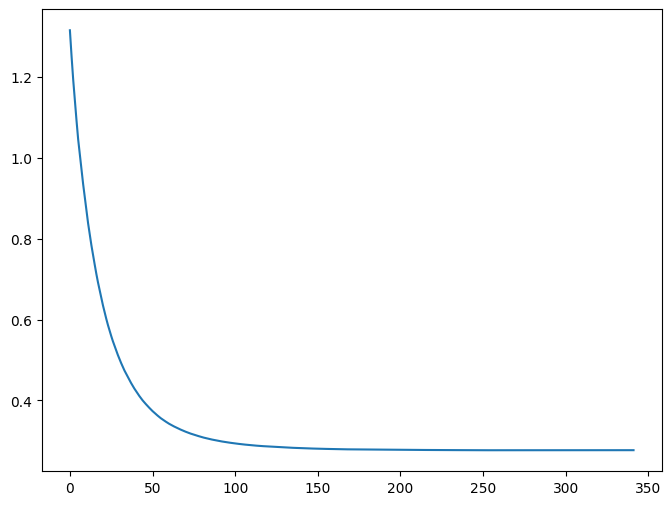

In [ ]:
# ================================
# PLOT: Training vs Validation mlogloss
# ================================

import matplotlib.pyplot as plt

# XGBoost stores evaluation results in the `evals_result()`
results = xgb_model.evals_result()

epochs = len(results["validation_0"]["mlogloss"])
x_axis = range(0, epochs)

plt.figure(figsize=(8,6))
plt.plot(x_axis, results["validation_0"]["mlogloss"], label="Validation mlogloss")
plt.plot(x_axis, results["train"]["mlogloss"], label="Training mlogloss")

plt.title("XGBoost Training vs Validation mlogloss")
plt.xlabel("Boosting Round")
plt.ylabel("mlogloss")
plt.legend()
plt.grid(True)
plt.show()

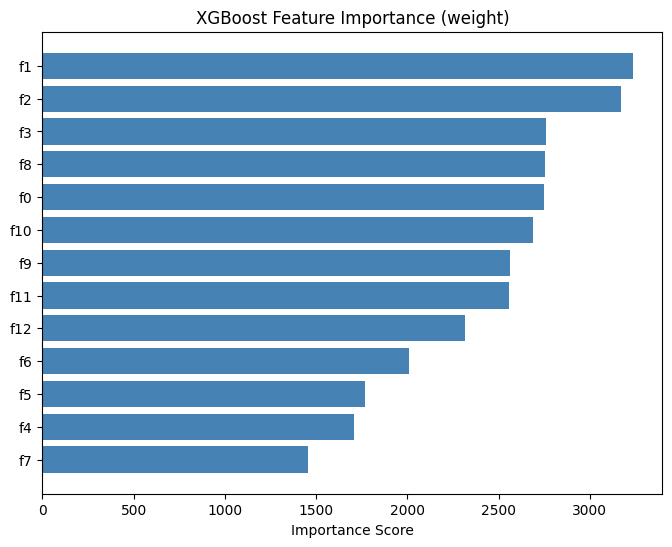

In [ ]:
# ================================
# PLOT: Feature Importance
# ================================

import matplotlib.pyplot as plt

# Get feature importance scores
importance = xgb_model.get_booster().get_score(importance_type="weight")

# Sort by importance
importance = dict(sorted(importance.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(8,6))
plt.barh(
    list(importance.keys()),
    list(importance.values()),
    color="steelblue"
)
plt.xlabel("Importance Score")
plt.title("XGBoost Feature Importance (weight)")
plt.gca().invert_yaxis()
plt.show()

XGBoost Testing

In [15]:
import os
import random
import numpy as np
import tensorflow as tf
import torch
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
!cp -r "/content/drive/MyDrive/Major Project/Test Datasets" /content/TestDatasets

In [6]:
dataset_path = "/content/TestDatasets"

class_names = ["AI", "CGI", "Real", "Edited"]
label_map = {name: idx for idx, name in enumerate(class_names)}

samples_per_class = 500

all_image_paths = []
all_labels = []

for class_name in class_names:
    class_folder = os.path.join(dataset_path, class_name)
    images = os.listdir(class_folder)

    #selected_images = random.sample(images, samples_per_class)

    for img_name in images:
        all_image_paths.append(os.path.join(class_folder, img_name))
        all_labels.append(label_map[class_name])

print("Total test samples:", len(all_image_paths))

Total test samples: 4356


In [7]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32)
    return img

In [11]:
meta_features = []
true_labels = []

batch_size = 16

for i in range(0, len(all_image_paths), batch_size):

    batch_paths = all_image_paths[i:i+batch_size]
    batch_labels = all_labels[i:i+batch_size]

    # -------------------------
    # Load and stack images
    # -------------------------
    batch_tf = [load_image(p).numpy() for p in batch_paths]
    batch_tf = np.stack(batch_tf)  # shape (B,224,224,3)

    # -------------------------
    # CNN input (no scaling)
    # -------------------------
    batch_tf_cnn = batch_tf.astype(np.float32)
    batch_tf_tensor_cnn = tf.convert_to_tensor(batch_tf_cnn)

    # -------------------------
    # AE input (scaled /255)
    # -------------------------
    batch_tf_ae = (batch_tf_cnn / 255.0).astype(np.float32)
    batch_tf_tensor_ae = tf.convert_to_tensor(batch_tf_ae)

    # -------------------------
    # CNN probabilities
    # -------------------------
    cnn_probs = cnn_base_forward(batch_tf_tensor_cnn).numpy()

    pAI_batch = cnn_probs[:, 0]
    pCGI_batch = cnn_probs[:, 1]
    pEdited_batch = cnn_probs[:, 2]
    pReal_batch = cnn_probs[:, 3]

    # -------------------------
    # Keras Autoencoders
    # -------------------------
    recon_ai = ai_ae_forward(batch_tf_tensor_ae).numpy()
    recon_cgi = cgi_ae_forward(batch_tf_tensor_ae).numpy()
    recon_edited = edited_ae_forward(batch_tf_tensor_ae).numpy()
    recon_real = real_ae_forward(batch_tf_tensor_ae).numpy()

    # Compute reconstruction errors FULLY in TensorFlow
    eAI_batch = tf.reduce_mean(
        tf.abs(batch_tf_tensor_ae - recon_ai), axis=[1,2,3]
    )

    eCGI_batch = tf.reduce_mean(
        tf.abs(batch_tf_tensor_ae - recon_cgi), axis=[1,2,3]
    )

    eEdited_batch = tf.reduce_mean(
        tf.abs(batch_tf_tensor_ae - recon_edited), axis=[1,2,3]
    )

    eReal_batch = tf.reduce_mean(
        tf.abs(batch_tf_tensor_ae - recon_real), axis=[1,2,3]
    )

    # Convert AE errors to numpy ONCE
    eAI_batch = eAI_batch.numpy()
    eCGI_batch = eCGI_batch.numpy()
    eEdited_batch = eEdited_batch.numpy()
    eReal_batch = eReal_batch.numpy()

    # -------------------------
    # Calculating relative errors
    # -------------------------
    total_e_batch=eAI_batch+eCGI_batch+eEdited_batch+eReal_batch
    eAI_relative = eAI_batch / total_e_batch
    eCGI_relative = eCGI_batch / total_e_batch
    eEdited_relative = eEdited_batch / total_e_batch
    eReal_relative = eReal_batch / total_e_batch

    # Calculating difference between 2nd minimum error and minimum error
    e_batch = np.array([eAI_batch, eCGI_batch, eEdited_batch, eReal_batch])
    e_batch.sort()
    secondmin_min_diff = e_batch[1] - e_batch[0]

    # =========================
    # Stack Meta Features
    # Order: [pAI, pCGI, pReal, pEdited, eAI, eCGI, eReal, eEdited]
    # =========================
    batch_meta = np.column_stack([
        pAI_batch,
        pCGI_batch,
        pEdited_batch,
        pReal_batch,
        eAI_batch,
        eCGI_batch,
        eEdited_batch,
        eReal_batch,
        eAI_relative,
        eCGI_relative,
        eEdited_relative,
        eReal_relative,
        secondmin_min_diff
    ])

    meta_features.append(batch_meta)
    true_labels.extend(batch_labels)

# Final test matrix
X_test = np.vstack(meta_features)
y_test = np.array(true_labels)

print("Meta feature shape:", X_test.shape)

Meta feature shape: (4356, 13)


In [12]:
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(
    "/content/drive/MyDrive/Major Project/Ensemble Model/meta_model_XGBoost_best.json"
)

print("XGBoost model loaded.")

XGBoost model loaded.


In [13]:
y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Test Accuracy: 0.7063820018365473

Classification Report:
              precision    recall  f1-score   support

           0     0.5855    0.7365    0.6524       539
           1     0.9777    0.8364    0.9015      2096
           2     0.4974    0.7275    0.5909       800
           3     0.4825    0.3746    0.4218       921

    accuracy                         0.7064      4356
   macro avg     0.6358    0.6687    0.6416      4356
weighted avg     0.7363    0.7064    0.7122      4356




Confusion Matrix:


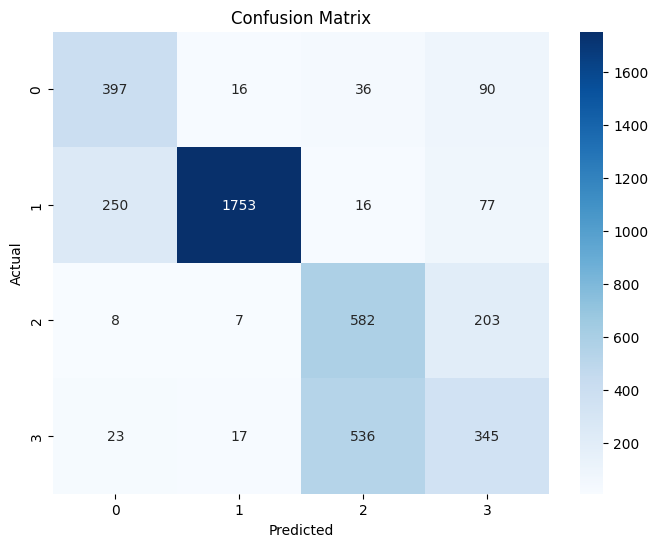

In [16]:
print("\nConfusion Matrix:")
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()